## Installing Gurobi


In [2]:
%pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 66.0 MB/s eta 0:00:00


## Princeton - Specific data

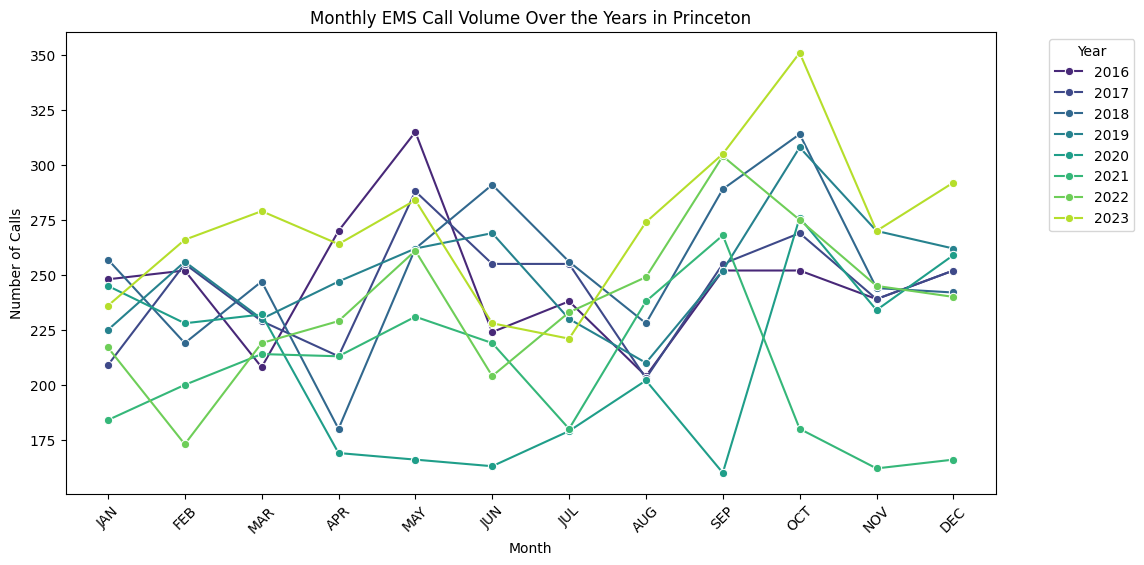

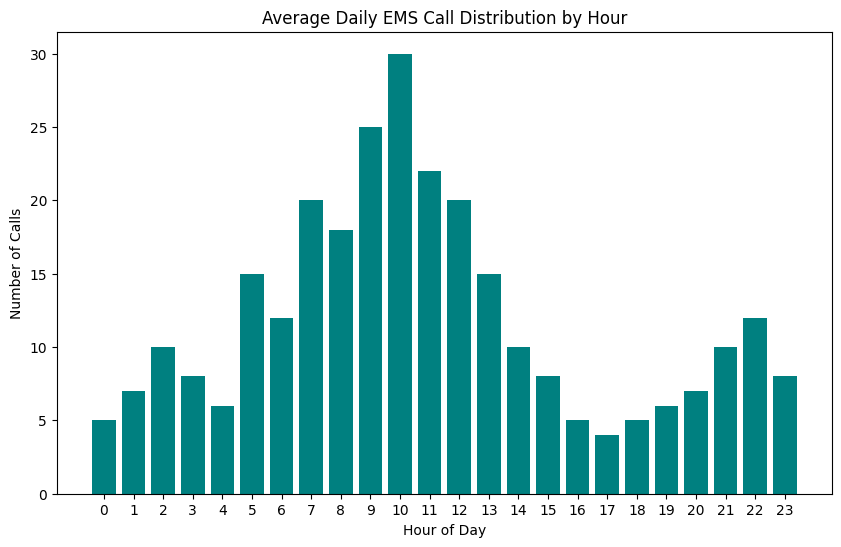

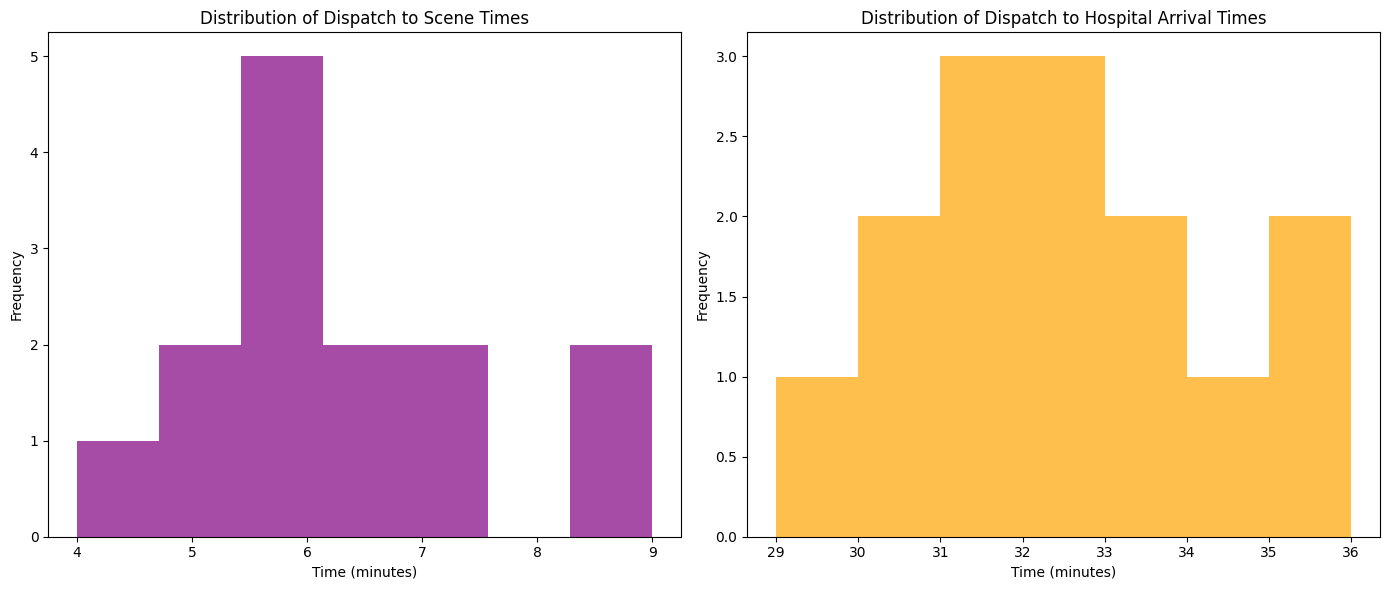

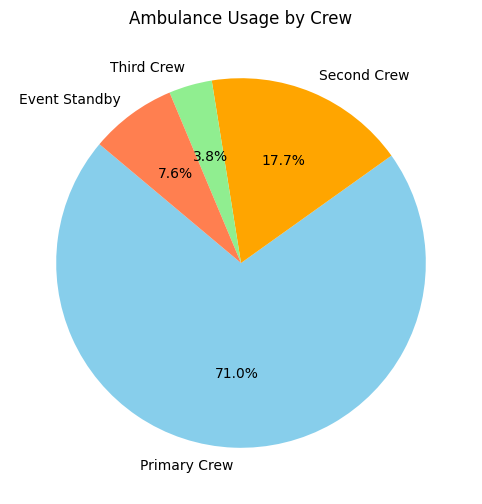

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Monthly Call Volume Data (example)
data = {
    "Year": ["2023", "2022", "2021", "2020", "2019", "2018", "2017", "2016"],
    "JAN": [236, 217, 184, 245, 225, 257, 209, 248],
    "FEB": [266, 173, 200, 228, 256, 219, 255, 252],
    "MAR": [279, 219, 214, 232, 230, 247, 229, 208],
    "APR": [264, 229, 213, 169, 247, 180, 213, 270],
    "MAY": [284, 261, 231, 166, 262, 262, 288, 315],
    "JUN": [228, 204, 219, 163, 269, 291, 255, 224],
    "JUL": [221, 233, 180, 179, 230, 256, 255, 238],
    "AUG": [274, 249, 238, 202, 210, 228, 203, 204],
    "SEP": [305, 304, 268, 160, 252, 289, 255, 252],
    "OCT": [351, 275, 180, 276, 308, 314, 269, 252],
    "NOV": [270, 245, 162, 234, 270, 244, 239, 239],
    "DEC": [292, 240, 166, 259, 262, 242, 252, 252]
}
df = pd.DataFrame(data)
df = df.melt(id_vars="Year", var_name="Month", value_name="Calls")
df["Month"] = pd.Categorical(df["Month"], categories=["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"], ordered=True)
df = df.sort_values(["Year", "Month"])

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Month", y="Calls", hue="Year", marker="o", palette="viridis")
plt.title("Monthly EMS Call Volume Over the Years in Princeton")
plt.xlabel("Month")
plt.ylabel("Number of Calls")
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

# Assuming daily data distribution by hour
hours = range(24)
calls_per_hour = [5, 7, 10, 8, 6, 15, 12, 20, 18, 25, 30, 22, 20, 15, 10, 8, 5, 4, 5, 6, 7, 10, 12, 8]

plt.figure(figsize=(10, 6))
plt.bar(hours, calls_per_hour, color='teal')
plt.title("Average Daily EMS Call Distribution by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Calls")
plt.xticks(hours)
plt.show()

# Example response times data
response_times = [4, 5.5, 6, 7, 5.2, 5.8, 9, 8.5, 4.8, 6.7, 6.3, 7.5, 6.1, 5.9]
hospital_times = [32, 31, 35, 30, 29, 33, 32, 31, 36, 34, 30, 32, 33, 31]

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.hist(response_times, bins=7, color='purple', alpha=0.7)
plt.title("Distribution of Dispatch to Scene Times")
plt.xlabel("Time (minutes)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(hospital_times, bins=7, color='orange', alpha=0.7)
plt.title("Distribution of Dispatch to Hospital Arrival Times")
plt.xlabel("Time (minutes)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

crew_data = {
    "Crew": ["Primary Crew", "Second Crew", "Third Crew", "Event Standby"],
    "Calls": [225, 56, 12, 24]
}
crew_df = pd.DataFrame(crew_data)

plt.figure(figsize=(8, 6))
plt.pie(crew_df["Calls"], labels=crew_df["Crew"], autopct='%1.1f%%', startangle=140, colors=['skyblue', 'orange', 'lightgreen', 'coral'])
plt.title("Ambulance Usage by Crew")
plt.show()

## CVRP-TW

In [6]:
from gurobipy import Model, GRB, quicksum
import numpy as np

# Parameters
num_demand_points = 10  # Number of locations where calls are generated
num_ambulances = 3      # Number of ambulances
num_depots = 2          # Number of ambulance depots

# Generate random demand (Poisson distribution)
np.random.seed(42)
demand = np.random.poisson(lam=5, size=num_demand_points)  # Average 5 calls per location

# Create a dummy cost matrix for travel between locations
all_locations = num_demand_points + num_depots
cost_matrix = np.random.randint(5, 25, size=(all_locations, all_locations))  # Random costs (5 to 25)
np.fill_diagonal(cost_matrix, 0)  # No cost for traveling to the same location

# Sets
J = list(range(num_demand_points))  # Demand points
K = list(range(1, num_ambulances + 1))  # Ambulances
D = list(range(num_demand_points, num_demand_points + num_depots))  # Depots

# Parameters for optimization
c = {(i, j): cost_matrix[i, j] for i in range(all_locations) for j in range(all_locations)}  # Travel cost
d = {j: demand[j] for j in J}  # Demand at each location
W = {k: 1 for k in K}  # Capacity per ambulance
a = {j: 0 for j in J}  # Earliest response time
b = {j: 20 for j in J}  # Latest response time

# Initialize model
model = Model("Ambulance Routing and Location Problem")

# Decision Variables
x = model.addVars(J, K, vtype=GRB.BINARY, name="x")  # 1 if ambulance k is assigned to incident j
y = model.addVars(J + D, J + D, K, vtype=GRB.BINARY, name="y")  # 1 if ambulance k travels from i to j
t = model.addVars(J, vtype=GRB.CONTINUOUS, name="t")  # Start time of service at incident j
unmet = model.addVars(J, vtype=GRB.CONTINUOUS, name="unmet")  # Unmet demand penalties

# Objective: Minimize total response time and unmet demand penalties
model.setObjective(
    quicksum(c[i, j] * y[i, j, k] for i in range(all_locations) for j in range(all_locations) for k in K)
    + quicksum(1000 * unmet[j] for j in J),  # High penalty for unmet demand
    GRB.MINIMIZE
)

# Constraints

# 1. Capacity Constraint: Each ambulance can handle up to its capacity of incidents
for k in K:
    model.addConstr(quicksum(x[j, k] for j in J) <= W[k], name=f"Capacity_{k}")

# 2. Time Window Constraints: Ensure response time is within [a_j, b_j] for each incident j
for j in J:
    model.addConstr(t[j] >= a[j], name=f"TimeWindowLower_{j}")
    model.addConstr(t[j] <= b[j], name=f"TimeWindowUpper_{j}")

# 3. Route Constraints: If ambulance k serves incident j, it must have a path to j
for k in K:
    for j in J:
        model.addConstr(quicksum(y[i, j, k] for i in range(all_locations)) == x[j, k], name=f"Route_{k}_{j}")

# 4. Depot Constraints: Each ambulance starts and ends at the depot
for k in K:
    model.addConstr(quicksum(y[d, j, k] for j in J for d in D) >= 1, name=f"DepotStart_{k}")
    model.addConstr(quicksum(y[j, d, k] for j in J for d in D) >= 1, name=f"DepotEnd_{k}")

# 5. Unmet demand constraints
for j in J:
    model.addConstr(quicksum(x[j, k] for k in K) + unmet[j] >= 1, name=f"UnmetDemand_{j}")

# Solve the model
model.optimize()

# Display results
if model.status == GRB.OPTIMAL:
    print("\nOptimal Solution:")
    for j in J:
        for k in K:
            if x[j, k].X > 0.5:
                print(f"Ambulance {k} is assigned to incident {j} with start time {t[j].X:.2f}")

    for k in K:
        for i in range(all_locations):
            for j in range(all_locations):
                if y[i, j, k].X > 0.5:
                    print(f"Ambulance {k} travels from location {i} to {j}")
else:
    print("No optimal solution found.")

Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (linux64 - "Ubuntu 22.04.3 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 69 rows, 482 columns and 600 nonzeros
Model fingerprint: 0xf91fe0e9
Variable types: 20 continuous, 462 integer (462 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e+00, 1e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+01]
Found heuristic solution: objective 7093.0000000
Presolve removed 56 rows and 442 columns
Presolve time: 0.01s
Presolved: 13 rows, 40 columns, 70 nonzeros
Found heuristic solution: objective 7059.0000000
Variable types: 0 continuous, 40 integer (40 binary)

Root relaxation: objective 7.034000e+03, 20 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incu

## ARTM

In [7]:
from gurobipy import Model, GRB, quicksum
import numpy as np

# Parameters
num_demand_points = 10  # Number of locations where calls are generated
num_bases = 5           # Number of potential ambulance base locations
num_ambulances = 3      # Number of ambulances

# Generate random demand (Poisson distribution)
np.random.seed(42)
demand = np.random.poisson(lam=5, size=num_demand_points)  # Average 5 calls per location

# Create a dummy travel time matrix between bases and demand points
travel_time_matrix = np.random.randint(5, 25, size=(num_bases, num_demand_points))  # Random times (5 to 25)

# Sets
I = list(range(num_demand_points))  # Demand points
J = list(range(num_bases))          # Potential base locations

# Parameters for optimization
t = {(j, i): travel_time_matrix[j, i] for j in J for i in I}  # Travel time between base j and demand point i
d = {i: demand[i] for i in I}                                # Demand at each location
p = num_ambulances                                          # Maximum number of ambulances to deploy

# Initialize model
model = Model("Average Response Time Model")

# Decision Variables
x = model.addVars(J, vtype=GRB.BINARY, name="x")  # 1 if a base is opened at location j
z = model.addVars(J, I, vtype=GRB.BINARY, name="z")  # 1 if demand point i is served by base j

# Objective: Minimize average response time weighted by demand
model.setObjective(
    quicksum(d[i] * t[j, i] * z[j, i] for j in J for i in I),
    GRB.MINIMIZE
)

# Constraints

# 1. Ensure each demand point is served by exactly one base
for i in I:
    model.addConstr(quicksum(z[j, i] for j in J) == 1, name=f"DemandCovered_{i}")

# 2. Ensure a base must be opened to serve a demand point
for j in J:
    for i in I:
        model.addConstr(z[j, i] <= x[j], name=f"BaseOpen_{j}_{i}")

# 3. Limit the total number of ambulances deployed
model.addConstr(quicksum(x[j] for j in J) <= p, name="AmbulanceLimit")

# Solve the model
model.optimize()

# Display results
if model.status == GRB.OPTIMAL:
    print("\nOptimal Solution:")
    print("Ambulance Bases Opened:")
    for j in J:
        if x[j].X > 0.5:
            print(f"Base at location {j} is opened.")
    print("\nDemand Coverage:")
    for i in I:
        for j in J:
            if z[j, i].X > 0.5:
                print(f"Demand point {i} is served by base {j}.")
else:
    print("No optimal solution found.")

Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (linux64 - "Ubuntu 22.04.3 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 61 rows, 55 columns and 155 nonzeros
Model fingerprint: 0x45ca9a14
Variable types: 0 continuous, 55 integer (55 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+01, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 3e+00]
Found heuristic solution: objective 714.0000000
Presolve time: 0.00s
Presolved: 61 rows, 55 columns, 155 nonzeros
Variable types: 0 continuous, 55 integer (55 binary)

Root relaxation: objective 3.240000e+02, 19 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0     324.0000000  324.00000 